# Notebook 6 — Regression for CA Professionals

**Goal:** Predict a **number** (revenue, expense, loan amount...) based on other columns.

**You will learn:**
1. What regression is — in one minute
2. Train / test split — why we never test on the same data we trained on
3. Simple linear regression — one input, one output
4. Multiple regression — several inputs
5. Measuring how good the model is (MAE, RMSE, R²)
6. Visualising predictions vs actual
7. A short mini-project

> All examples predict daily store revenue from ads spend, footfall, weekend/festival flags — using `data/daily_revenue.csv`.

---

## 1. What is regression?

Regression answers: **"Given some inputs, what number should I expect?"**

Real CA-style examples:
- Predict **next month's revenue** from ad spend, footfall, season.
- Predict **a property's value** from area, location, age.
- Predict **electricity expense** from production output.

The model **learns** the relationship from past data, then applies it to new rows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

daily = pd.read_csv("data/daily_revenue.csv")
print("Shape:", daily.shape)
daily.head()

Shape: (90, 6)


,Date,Ads_Spend,Footfall,Is_Weekend,Is_Festival,Revenue
0,2024-07-16,17479.0,321,0,0,229308.0
1,2024-07-17,20050.0,229,0,0,206190.0
2,2024-07-18,20294.0,462,0,1,309754.0
3,2024-07-19,4684.0,190,0,0,77360.0
4,2024-07-20,9358.0,182,1,0,144554.0


## 2. Train / Test split — the golden rule

Never check a model against the same rows you taught it. Split your data into two parts:

| Subset | Use                                |
|--------|------------------------------------|
| Train  | The model **learns** from this data |
| Test   | We check the model on data it has never seen |

A typical split is **80% train, 20% test**.

In [2]:
from sklearn.model_selection import train_test_split

X = daily[["Ads_Spend"]]   # input column(s) — must be 2-D
y = daily["Revenue"]       # what we want to predict

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train rows:", len(X_train))
print("Test  rows:", len(X_test))

Train rows: 72
Test  rows: 18


## 3. Simple linear regression — one input

The model learns the line:  `Revenue = m × Ads_Spend + c`

In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Slope (m): {model.coef_[0]:.2f}")
print(f"Intercept (c): {model.intercept_:.0f}")
print(f"→ Equation: Revenue = {model.coef_[0]:.2f} * Ads_Spend + {model.intercept_:.0f}")

Slope (m): 7.58
Intercept (c): 95465
→ Equation: Revenue = 7.58 * Ads_Spend + 95465


In [4]:
# Predict on the held-out test set
y_pred = model.predict(X_test)

pd.DataFrame({"Actual": y_test.values[:10],
              "Predicted": y_pred[:10].round(0)}).head(10)

,Actual,Predicted
0,301305.0,199253.0
1,165756.0,177601.0
2,304694.0,248972.0
3,198129.0,200542.0
4,229308.0,227979.0
5,158795.0,176699.0
6,179067.0,192347.0
7,216391.0,240920.0
8,131883.0,167783.0
9,249144.0,263748.0


### Practice 1
Use the model to predict the revenue when `Ads_Spend = 10,000`.

Hint: call `model.predict(pd.DataFrame({"Ads_Spend":[10000]}))`.

In [5]:
# Your turn:

<details><summary>Show solution</summary>

In [6]:
new_input = pd.DataFrame({"Ads_Spend":[10000]})
print("Predicted revenue:", model.predict(new_input)[0].round(0))

Predicted revenue: 171278.0


</details>

## 4. How good is the model? — MAE, RMSE, R²

| Metric  | Meaning                                            | Better when |
|---------|----------------------------------------------------|-------------|
| **MAE** | Mean Absolute Error — avg NPR difference          | smaller     |
| **RMSE**| Root Mean Squared Error — penalises big mistakes  | smaller     |
| **R²**  | % of variation in revenue the model explains      | closer to 1 |

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  : NPR {mae:,.0f}")
print(f"RMSE : NPR {rmse:,.0f}")
print(f"R²   : {r2:.3f}    ({r2*100:.1f}% of variation explained)")

MAE  : NPR 25,929
RMSE : NPR 35,997
R²   : 0.666    (66.6% of variation explained)


## 5. Visualising the fit

The scatter shows actual points; the red line is what the model learned.

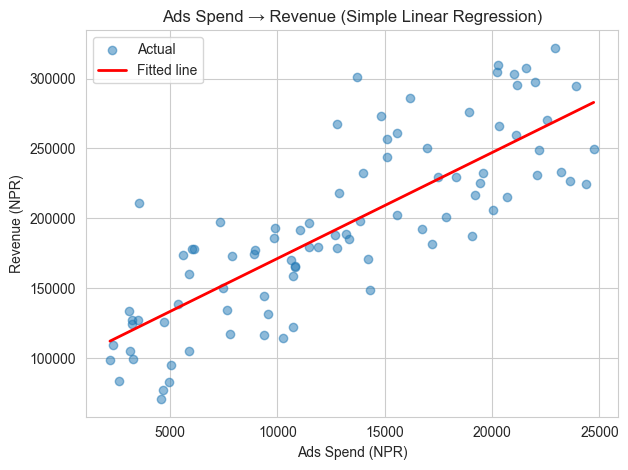

In [8]:
plt.scatter(daily["Ads_Spend"], daily["Revenue"], alpha=0.5, label="Actual")
xs = np.linspace(daily["Ads_Spend"].min(), daily["Ads_Spend"].max(), 50)
ys = model.predict(pd.DataFrame({"Ads_Spend": xs}))
plt.plot(xs, ys, color="red", linewidth=2, label="Fitted line")
plt.xlabel("Ads Spend (NPR)")
plt.ylabel("Revenue (NPR)")
plt.title("Ads Spend → Revenue (Simple Linear Regression)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Multiple regression — using several inputs

Real revenue depends on more than just ads spend. Add **footfall**, **weekend** and **festival** flags and let the model use all of them at once.

In [9]:
X = daily[["Ads_Spend", "Footfall", "Is_Weekend", "Is_Festival"]]
y = daily["Revenue"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

multi = LinearRegression().fit(X_tr, y_tr)

# Coefficients tell us the impact of each input
coefs = pd.Series(multi.coef_, index=X.columns).round(2)
print("Intercept :", multi.intercept_.round(2))
print(coefs.to_string())

Intercept : 7106.53
Ads_Spend          8.09
Footfall         264.64
Is_Weekend     12921.49
Is_Festival    35531.46


In [10]:
y_pred = multi.predict(X_te)
print(f"MAE  : NPR {mean_absolute_error(y_te, y_pred):,.0f}")
print(f"RMSE : NPR {np.sqrt(mean_squared_error(y_te, y_pred)):,.0f}")
print(f"R²   : {r2_score(y_te, y_pred):.3f}")

MAE  : NPR 13,242
RMSE : NPR 18,856
R²   : 0.908


### Practice 2
Use the **multiple** model to predict revenue for a day with:
- Ads_Spend = 12,000
- Footfall = 300
- Is_Weekend = 0
- Is_Festival = 1

In [11]:
# Your turn:

<details><summary>Show solution</summary>

In [12]:
new_day = pd.DataFrame({
    "Ads_Spend":[12000],
    "Footfall":[300],
    "Is_Weekend":[0],
    "Is_Festival":[1],
})
print("Predicted revenue:", multi.predict(new_day)[0].round(0))

Predicted revenue: 219075.0


</details>

## 7. Actual vs Predicted — diagnostic plot

A good model has its dots **close to the 45-degree line**.

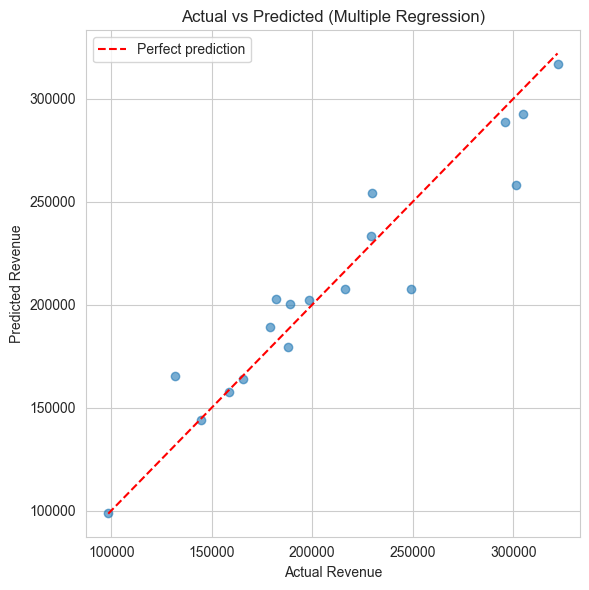

In [13]:
plt.figure(figsize=(6,6))
plt.scatter(y_te, y_pred, alpha=0.6)
lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted (Multiple Regression)")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Mini-Project — predict monthly company revenue

Imagine you are given the past 12 months data:

| Month | Marketing_Spend | Salesmen | Units_Sold | Revenue |
|------|---|---|---|---|

In [14]:
toy = pd.DataFrame({
    "Marketing_Spend":[50000,55000,60000,45000,70000,80000,75000,85000,90000,100000,110000,120000],
    "Salesmen":       [5, 5, 6, 6, 7, 7, 7, 8, 8, 9, 9, 10],
    "Units_Sold":     [420, 465, 510, 380, 540, 605, 580, 660, 700, 760, 820, 880],
    "Revenue":        [1250000, 1380000, 1520000, 1120000, 1620000, 1780000, 1700000,
                       1950000, 2080000, 2250000, 2400000, 2580000],
})
toy

,Marketing_Spend,Salesmen,Units_Sold,Revenue
0,50000,5,420,1250000
1,55000,5,465,1380000
2,60000,6,510,1520000
3,45000,6,380,1120000
4,70000,7,540,1620000
5,80000,7,605,1780000
6,75000,7,580,1700000
7,85000,8,660,1950000
8,90000,8,700,2080000
9,100000,9,760,2250000


**Your tasks:**

1. Split the data into train (80%) and test (20%) — use `random_state=0`.
2. Fit a `LinearRegression` using all three inputs.
3. Print the coefficients of each input.
4. Report MAE, RMSE and R² on the test set.
5. Predict the revenue for a month with: Marketing_Spend = 95,000, Salesmen = 9, Units_Sold = 750.

In [15]:
# Your code here

<details><summary>Show solution</summary>

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = toy[["Marketing_Spend","Salesmen","Units_Sold"]]
y = toy["Revenue"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0)

m = LinearRegression().fit(X_tr, y_tr)
print("Coefs   :", dict(zip(X.columns, m.coef_.round(2))))
print("Intercept:", m.intercept_.round(2))

p = m.predict(X_te)
print()
print(f"MAE  : {mean_absolute_error(y_te, p):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_te, p)):,.0f}")
print(f"R²   : {r2_score(y_te, p):.3f}")

new_month = pd.DataFrame({"Marketing_Spend":[95000],"Salesmen":[9],"Units_Sold":[750]})
print("\nPredicted revenue:", m.predict(new_month)[0].round(0))

Coefs   : {'Marketing_Spend': np.float64(-4.46), 'Salesmen': np.float64(1300.18), 'Units_Sold': np.float64(3576.44)}
Intercept: -41061.98

MAE  : 15,013
RMSE : 19,613
R²   : 0.998

Predicted revenue: 2229479.0


</details>

---
### What's next?
Now we can predict numbers. The final notebook (`07_Classification`) tackles the other big question — **predicting categories** (yes/no, default/not, fraud/not). The workflow is the same; only the metric changes.